In [1]:
from pathlib import Path
import os

import pandas as pd


root = Path("..")

parquet_path = Path(root / "data/postauto.parquet")
df = pd.read_parquet(parquet_path)
print(f"DataFrame contains {len(df)} rows")
df.head()

DataFrame contains 519177 rows


,agency_id,route_id,route_short_name,trip_id,service_id,stop_sequence,arrival_time,departure_time,stop_id,stop_name,stop_lat,stop_lon
0,801,96-100-0-j25-1,220,2.TA.96-100-0-j25-1.8.H,TA,1,18:27:00,18:27:00,8571330,"Reichenbach i. K., Bahnhof",46.625525,7.690208
1,801,96-100-0-j25-1,220,2.TA.96-100-0-j25-1.8.H,TA,2,18:28:00,18:28:00,8571331,"Reichenbach i. K., Bären",46.625432,7.694187
2,801,96-100-0-j25-1,220,2.TA.96-100-0-j25-1.8.H,TA,3,18:30:00,18:30:00,8583254,"Scharnachtal, Halten",46.620608,7.697223
3,801,96-100-0-j25-1,220,2.TA.96-100-0-j25-1.8.H,TA,4,18:32:00,18:32:00,8507766,"Scharnachtal, Viesen",46.617979,7.697807
4,801,96-100-0-j25-1,220,2.TA.96-100-0-j25-1.8.H,TA,5,18:33:00,18:33:00,8571332,"Scharnachtal, Schulhaus",46.614709,7.698158


In [2]:
from trip_stitcher.models import Route, Trip, Stop


route_dict = dict((route.id, route) for route in Route.list_from_dataframe(df)) # Route dictionary for trip lookup
trip_dict = dict((trip.id, trip) for trip in Trip.list_from_dataframe(df)) # Trip dictionary for trip lookup
stop_dict = dict((stop.id, stop) for stop in Stop.list_from_dataframe(df)) # Trip dictionary for trip lookup

route_id = "96-241-7-j25-1"
trip = trip_dict[route_dict[route_id].trips[0]]
trip_geometry = trip.download_geometry(stop_dict)
trip

Trip(id='1.TA.96-241-7-j25-1.9.H', route='96-241-7-j25-1', stops=['8573902', '8580266', '8580494', '8580493', '8580271', '8573904', '8580906', '8580501', '8580502', '8580907', '8580503', '8582765', '8579947', '8579949', '8579950', '8573887'], arrival_times=['20:18:00', '20:19:00', '20:20:00', '20:21:00', '20:22:00', '20:24:00', '20:25:00', '20:28:00', '20:28:00', '20:29:00', '20:29:00', '20:35:00', '20:35:00', '20:36:00', '20:37:00', '20:41:00'], estimated_energy_demand=None)

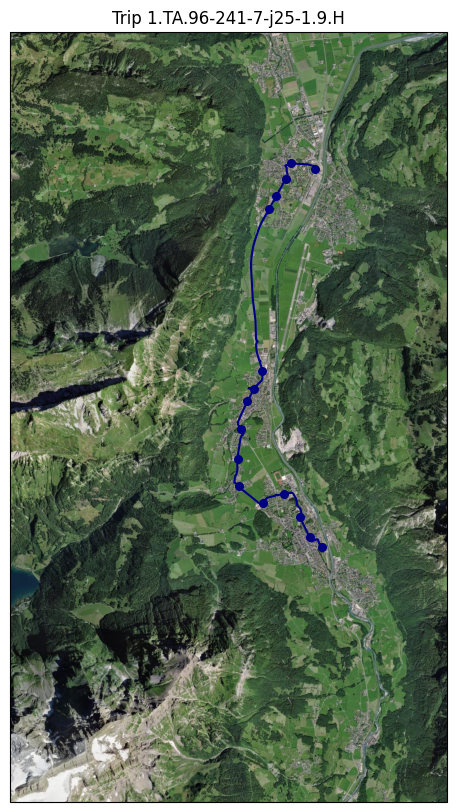

In [3]:
import cartopy.crs as ccrs
import cartopy.geodesic as cgeo
import cartopy.io.img_tiles as cimgt
import matplotlib.pyplot as plt


# Create a tiler for OpenStreetMap
tiler = cimgt.GoogleTiles(style="satellite")   # Satellite tiles
mercator = tiler.crs  # The CRS used by the tiles (Web Mercator)

# Create the plot
fig = plt.figure(figsize=(10,10))
ax = plt.axes(projection=mercator)

# Add the map tiles
ax.add_image(tiler, 14)  # zoom level 14

# Set extent
extent = [9.0, 9.1, 47.0, 47.12]
ax.set_extent(extent, crs=ccrs.PlateCarree())

ax.plot(trip_geometry.lon, trip_geometry.lat, transform=ccrs.PlateCarree(), c="navy")
ax.scatter([stop_dict[stop_id].lon for stop_id in trip.stops], [stop_dict[stop_id].lat for stop_id in trip.stops], s=30, transform=ccrs.PlateCarree(), c="navy")

plt.title(f"Trip {trip.id}")
plt.show()

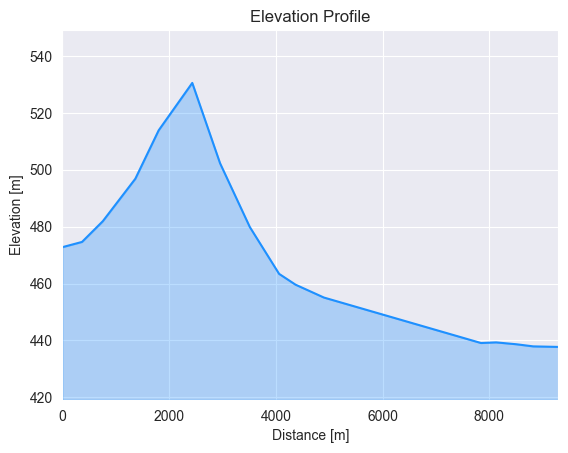

In [4]:
import seaborn as sns

from trip_stitcher.elevation import ElevationOracle


elevation_oracle = ElevationOracle()
trip_geometry = trip.download_geometry(stop_dict, elevation_oracle=elevation_oracle)


sns.set_style("darkgrid")
plt.plot(trip_geometry.cumulative_distance, trip_geometry.elevation, c="dodgerblue")
plt.fill_between(
    trip_geometry.cumulative_distance,
    trip_geometry.elevation,
    min(trip_geometry.elevation) - 0.2 * (max(trip_geometry.elevation) - min(trip_geometry.elevation)),
    color="dodgerblue",
    alpha=0.3
)
plt.title("Elevation Profile")
plt.xlabel("Distance [m]")
plt.ylabel("Elevation [m]")
plt.xlim(min(trip_geometry.cumulative_distance), max(trip_geometry.cumulative_distance))
plt.ylim(
    (
        min(trip_geometry.elevation) - 0.2 * (max(trip_geometry.elevation) - min(trip_geometry.elevation)),
        max(trip_geometry.elevation) + 0.2 * (max(trip_geometry.elevation) - min(trip_geometry.elevation))
    )
)
plt.show()

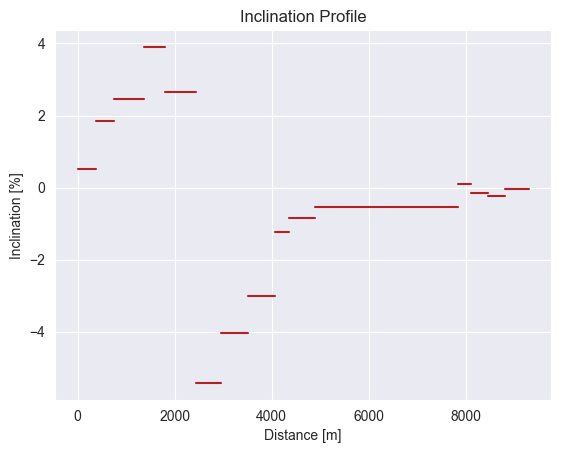

In [5]:
inclination = []
for d, e1, e2 in zip(trip_geometry.distance, trip_geometry.elevation[:-1], trip_geometry.elevation[1:]):
    if d == 0:
        inclination.append(0) # this will not be seen on the plot since the length of the line is zero
    else:
        inclination.append(100 * (e2 - e1) / d)

for inc, d1, d2 in zip(inclination, trip_geometry.cumulative_distance[:-1], trip_geometry.cumulative_distance[1:]):
    plt.plot([d1, d2], [inc, inc], c="firebrick")

plt.title("Inclination Profile")
plt.xlabel("Distance [m]")
plt.ylabel("Inclination [%]")

plt.show()

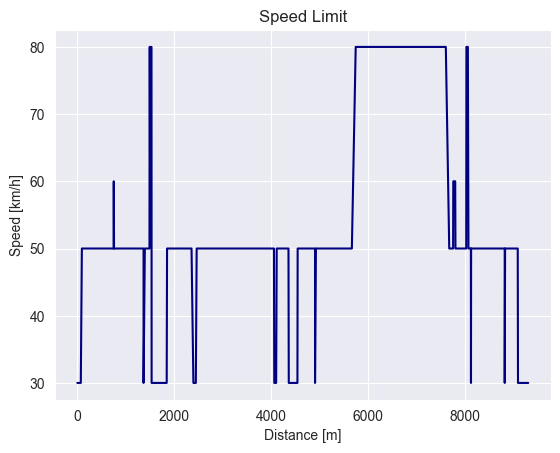

In [6]:
plt.plot(trip_geometry.cumulative_distance[1:], trip_geometry.speed_limit, c="navy")
plt.title("Speed Limit")
plt.ylabel("Speed [km/h]")
plt.xlabel("Distance [m]")
plt.show()

In [7]:
from loguru import logger

logger.remove() # prevent ocsept from logging

from ocsept.models.transport.itinerary import Segment, TravelItinerary, Waypoint


def create_itinerary_from_trip_geometry(trip_geometry):
    elements = [Waypoint(maximum_speed_limit="0 km/h", elevation=f"{trip_geometry.elevation[0]} m")]
    for sl, el, halt, d in zip(trip_geometry.speed_limit, trip_geometry.elevation[1:], trip_geometry.is_stop[1:], trip_geometry.distance):
        if d <= 0:
            continue
        elements.append(Segment(length=f"{d} m", maximum_speed_limit=f"{sl} km/h"))
        waypoint_sl = 0.0 if halt else sl
        elements.append(Waypoint(maximum_speed_limit=f"{waypoint_sl} km/h", elevation=f"{el} m"))
    return TravelItinerary.from_elements(*elements)

itinerary = create_itinerary_from_trip_geometry(trip_geometry)

In [8]:
from ocsept.data.generation.speed.time_optimal import TimeOptimalStrategy
from ocsept.models.transport.comfort import RidingComfort
from ocsept.models.transport.mission import DrivingMission as OcseptDrivingMission
from ocsept.simulation.qss import LongitudinalVehicleDynamics

from trip_stitcher.utils import suppress_stdout
from trip_stitcher.vehicles.mega import bus

comfort = RidingComfort()
speed_profile = TimeOptimalStrategy().process(itinerary, bus, comfort)
mission = OcseptDrivingMission(
    name="Fastest possible travel speed",
    time=speed_profile.time,
    speed=speed_profile.speed,
    inclination=itinerary.get_inclination(speed_profile.distance),
    payload="0 kg",
)
with suppress_stdout():
    vehicle_dynamics = LongitudinalVehicleDynamics.of(bus, mission)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



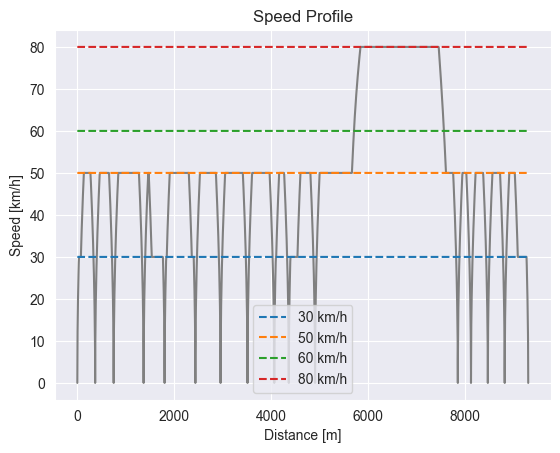

In [10]:
plt.plot(speed_profile.distance.magnitude, speed_profile.speed.magnitude, c="gray")
for speed_limit in [30, 50, 60, 80]:
    plt.plot(
        speed_profile.distance.magnitude,
        [speed_limit] * len(speed_profile.distance),
        label=f"{speed_limit} km/h",
        linestyle="dashed",
    )
plt.xlabel("Distance [m]")
plt.ylabel("Speed [km/h]")
plt.legend()
plt.title("Speed Profile")
plt.show()

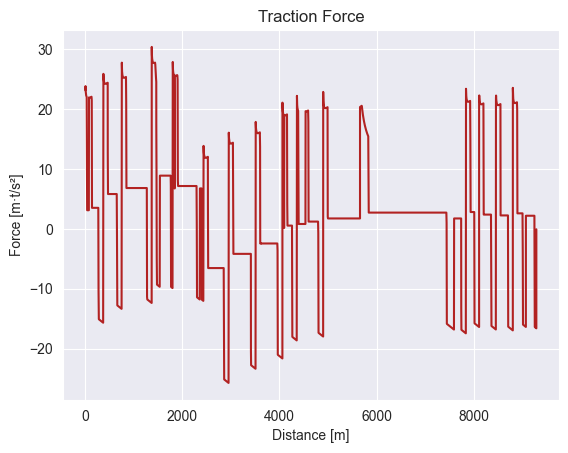

In [11]:
plt.plot(speed_profile.distance.magnitude, vehicle_dynamics.traction_force.magnitude, c="firebrick")
plt.xlabel("Distance [m]")
plt.ylabel(f"Force [{vehicle_dynamic.traction_force.units}]")
plt.title("Traction Force")
plt.show()

In [12]:
# from optool.uom import Quantity


average_velocity = speed_profile.speed[:-1] + speed_profile.speed[1:] / 2

In [13]:
p_mech = average_velocity * vehicle_dynamics.traction_force[:-1]

In [40]:
import numpy as np


efficiency = 0.9
propulsion_power = np.where(p_mech >= 0, p_mech / efficiency, p_mech * efficiency)
propulsion_energy = np.sum(np.diff(speed_profile.time) * propulsion_power).to("J")

In [42]:
propulsion_energy

<Quantity(40330774.6, 'joule')>